# K Means Clustering


We will use car data to perform k means clustering using sklearn packages. Overview of different clustering algorithms as supported by `sklearn` can be found at: http://scikit-learn.org/stable/modules/clustering.html

In [1]:
import numpy as np
import pandas as pd

import matplotlib.cm as cm
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import os

%matplotlib inline


## Preparing Data

Read data from a specified location


In [2]:
from google.colab import drive
drive.mount('/content/files')

Mounted at /content/files


In [3]:
os.getcwd()

'/content'

In [4]:
path_name = "/content/files/MyDrive/ML_using_Python/Python_Code/"
os.chdir(path_name)
os.getcwd()

'/content/files/MyDrive/ML_using_Python/Python_Code'

In [ ]:
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

In [5]:
raw_df = pd.read_csv( "./Python_clustering/data/Kmeans_Car data.csv",
                        sep = ',', na_values = ['', ' '])

raw_df.columns = raw_df.columns.str.lower().str.replace(' ', '_')
raw_df

,brand,car_models,price_(inr),mileage,seating_capacity,vehicle_type,fuel_type,transmission,parking_sensor,airbag,cruise_control,keyless_entry,alloy_wheels,abs,climate_control,rear_ac_vent,power_steering
0,Tata,Tata Nano Std BSIII,141898,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
1,Tata,Tata Nano Std,145000,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
2,Tata,Tata Nano 2013 STD,150000,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
3,Tata,Tata Nano Cx BSIII,171489,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
4,Tata,Tata Nano Cx,191125,25.40,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,Rolls Royce,Rolls Royce Wraith Coupe,46000000,12.24,4,Coupe,Petrol,Automatic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes
1004,Maybach,Maybach 57 S,48500000,8.47,4,Luxury,Petrol,Automatic,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1005,Conquest,Conquest Evade SUV,85000000,5.00,6,SUV,Diesel,Automatic,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes
1006,Bugatti,Bugatti Veyron 16.4 Grand Sport,120000000,5.20,2,Convertible,Petrol,Automatic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes



## 2. Extract Features and Standardize

Two ways to extract the features:

> * use `pd.filter` and pass the list of features to extract for scaling
* Use `pd.drop` and pass the list of features which need not be extracted

The feature can also be extracted by using `dataframeName[[<name of features>]]`


In [6]:
#feature_df = raw_df[['price_(inr)','mileage', 'seating_capacity']]

feature_df = raw_df.filter({'price_(inr)','mileage', 'seating_capacity'}, axis =1)
col_names = feature_df.columns

row_index = raw_df.iloc[:,2]
#row_index

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(feature_df))

scaled_data.columns = col_names
#scaled_data.index = row_index

scaled_data.head()

,mileage,seating_capacity,price_(inr)
0,1.515521,-0.965699,-0.412253
1,1.515521,-0.965699,-0.411900
2,1.515521,-0.965699,-0.411331
3,1.515521,-0.965699,-0.408888
4,1.515521,-0.965699,-0.406656



## 3. k means clustering and quality metrics

The Euclidian distance between any two observations within the cluster will be lesser than the observations between clusters. This is used to derive ideal number of clusters and quality of clusters. Some of the metrics using this information are

* **Elbow method:**

  For each point in cluster C, calculate within cluster sum of squared distance.  WCSS is the sum of squared distance between each point of the cluster and the centroid of the cluster.

  WCSS is maximum for K =1. If the delta difference in WCSS between Cluster K to Cluster K+1 is small, then the optimal cluster size is K.


*  **Calinski and Harabasz Index (CH Index):**

  $CH(k) =\frac{ \frac{B(k)}{k-1}}{\frac{W(k)}{n-k}}$

  Where CH(k) is the Calinski and Harabasz index with k-clusters (k > 1), B(k) and W(k) are the between and within clusters sum of squared variations with k clusters.The optimal K value is the one with maximum CH Index.

* **Silhouette Score**.

  Let a(i) be the average distance between an observation i and other points in the cluster to which observation i belongs.  Let b(i) be the minimum average distance between observation i and observations in other clusters.  Then the Silhouette statistic is defined by:

  $ S(i) = \frac{b(i)-a(i)}{Max(a(i),b(i))}$

  Silhouette analysis can be used to study the separation distance between the resulting clusters. The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like number of clusters visually. This measure has a range of [-1, 1].

  Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster.



Overview of different clustering algorithms as supported by `sklearn` can be found at: http://scikit-learn.org/stable/modules/clustering.html


## Elbow Method - Optimal Clusters

For cluster = 2, SSE/WCSS is 2100.171343330566
For cluster = 3, SSE/WCSS is 1435.8390450929458
For cluster = 4, SSE/WCSS is 1073.3532457220786
For cluster = 5, SSE/WCSS is 748.5516552473758
For cluster = 6, SSE/WCSS is 551.6803540338287
For cluster = 7, SSE/WCSS is 440.9688400239943
For cluster = 8, SSE/WCSS is 374.17815901127244
For cluster = 9, SSE/WCSS is 310.5682681004351
For cluster = 10, SSE/WCSS is 262.54371163602417
For cluster = 11, SSE/WCSS is 236.36624108501042
For cluster = 12, SSE/WCSS is 220.93825425744825
For cluster = 13, SSE/WCSS is 205.64577694086296
For cluster = 14, SSE/WCSS is 185.66208357043186
For cluster = 15, SSE/WCSS is 167.28764739432046
For cluster = 16, SSE/WCSS is 158.0904052933767
For cluster = 17, SSE/WCSS is 138.2156653268327
For cluster = 18, SSE/WCSS is 129.66336553453868
For cluster = 19, SSE/WCSS is 121.44991512109986


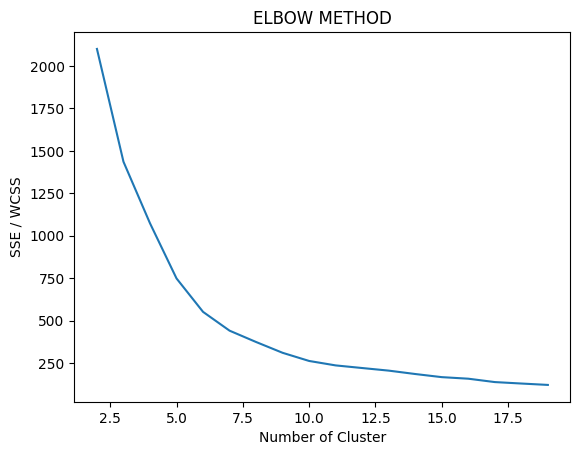

In [8]:
#data = pd.DataFrame({'x':x_axis, 'y':y_axis})

sse = {}

for k in range(2,20): # Number of clusters which we are checking
  kmeans = KMeans(n_clusters=k,max_iter=100,n_init=10).fit(scaled_data)
  #scaled_data['clusters'] = kmeans.labels_
  # wcss is stored in kmeans.inertia_
  sse[k] = kmeans.inertia_
  print("For cluster = {}, SSE/WCSS is {}".format(k, sse[k]))

plt.figure()
plt.plot(list(sse.keys()),list(sse.values()))
plt.xlabel("Number of Cluster")
plt.ylabel("SSE / WCSS")
plt.title("ELBOW METHOD")
plt.show()


For cluster = 2, SSE/WCSS is 0.5530059216268258
For cluster = 3, SSE/WCSS is 0.5446322260802625
For cluster = 4, SSE/WCSS is 0.5553547579821115
For cluster = 5, SSE/WCSS is 0.5660240029009911
For cluster = 6, SSE/WCSS is 0.48143042535105085
For cluster = 7, SSE/WCSS is 0.48625642544680886
For cluster = 8, SSE/WCSS is 0.49812032006262014
For cluster = 9, SSE/WCSS is 0.4918852532799447
For cluster = 10, SSE/WCSS is 0.46883686029003147
For cluster = 11, SSE/WCSS is 0.4633806577862704
For cluster = 12, SSE/WCSS is 0.4661034876722877
For cluster = 13, SSE/WCSS is 0.47561051744877064
For cluster = 14, SSE/WCSS is 0.444679948619417
For cluster = 15, SSE/WCSS is 0.4595345514644303
For cluster = 16, SSE/WCSS is 0.44719695322771924
For cluster = 17, SSE/WCSS is 0.4363562896043187
For cluster = 18, SSE/WCSS is 0.4514968713679261
For cluster = 19, SSE/WCSS is 0.4416973974377571


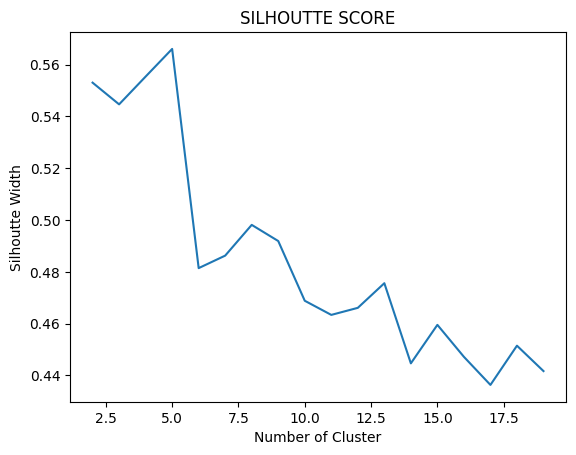

In [9]:
sil = {}

for k in range(2,20): # Number of clusters which we are checking
  #kmeans = KMeans(n_clusters=k,max_iter=100, n_init=10).fit(scaled_data)
  kmeans = KMeans(n_clusters=k, n_init=10, random_state=10).fit(scaled_data)
  label = kmeans.labels_
  sil_coeff = silhouette_score(scaled_data,label,metric = 'euclidean')
  #print('For cluster= {}, Silhouette Coefficient is {}'.format(k,sil_coeff))
  sil[k] = sil_coeff
  print("For cluster = {}, SSE/WCSS is {}".format(k, sil[k]))


plt.figure()
plt.plot(list(sil.keys()),list(sil.values()))
plt.xlabel("Number of Cluster")
plt.ylabel("Silhoutte Width")
plt.title("SILHOUTTE SCORE")
plt.show()

The silhouette plot shows that the none of the clusters are a good pick for the given data due to the presence of clusters with below average silhouette scores and also due to wide fluctuations in the size of the silhouette plots.

Assume you have found a good cluster and want to find the observations which went into the cluster. Below code chunk will implement the same:

In [10]:
final_kmeans = KMeans(n_clusters=10, init = "k-means++", n_init=10, random_state=10 ).fit(scaled_data)

#y_kmeans = final_kmeans.predict(scaled_data)

In [11]:
labels = final_kmeans.labels_
labels

raw_df['Cluster'] = labels

raw_df.head()

,brand,car_models,price_(inr),mileage,seating_capacity,vehicle_type,fuel_type,transmission,parking_sensor,airbag,cruise_control,keyless_entry,alloy_wheels,abs,climate_control,rear_ac_vent,power_steering,Cluster
0,Tata,Tata Nano Std BSIII,141898,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,5
1,Tata,Tata Nano Std,145000,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,5
2,Tata,Tata Nano 2013 STD,150000,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,5
3,Tata,Tata Nano Cx BSIII,171489,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,5
4,Tata,Tata Nano Cx,191125,25.4,4,Hatchback,Petrol,Manual,No,No,No,No,No,No,No,No,No,5


In [ ]:
#raw_df.to_csv("Car_withCluster.csv")

## Exercise:

Use Kmeans from sklearn.cluster to build Kmeans Clustering using the beer data. What challenges do you encounter?

## Optional 1

To get the car names in any cluster

In [12]:
def ClusterIndicesComp(clustNum, labels_array): #list comprehension
    return np.array([i for i, x in enumerate(labels_array) if x == clustNum])

In [13]:
index = ClusterIndicesComp(2, final_kmeans.labels_)

index

array([389, 756, 792, 861, 862, 863, 872, 873, 887, 888, 889, 890, 891,
       892, 896, 897, 898, 899, 900, 922, 923, 946, 948, 950, 951, 957,
       958, 959, 960, 961, 969, 970, 971, 972, 983, 989])

In [14]:
car_name = []
for i in index:
    car_name.append(raw_df.iloc[i,1])

In [15]:
car_name

['San Motors Storm 1.2',
 'DC Avanti 2.0 L',
 'Caterham 7 Classic',
 'Audi TT 2.0 TFSI',
 'Nissan 370Z MT',
 'Nissan 370Z AT',
 'BMW Z4 35i',
 'BMW Z4 35i DPT',
 'Porsche Boxster 3.0',
 'Porsche Boxster S',
 'Porsche Cayman 3.0L',
 'Porsche Cayman S',
 'Mercedes Benz SLK Class SLK 350',
 'Mercedes Benz SLK Class 55 AMG',
 'Jaguar XK R S Coupe 5.0L Supercharged',
 'Jaguar XK R Coupe Special Edition',
 'Jaguar XK R 5.0L V8 Petrol Coupe',
 'Jaguar XK R 5.0L V8 Petrol Convertible',
 'Jaguar XK R Convertible Special Edition',
 'Mercedes Benz SL Class SL 350',
 'Mercedes Benz SL Class SL 500',
 'Porsche 911 Carrera Cabriolet',
 'Porsche 911 Carrera 4 Cabriolet',
 'Porsche 911 Carrera S Cabriolet',
 'Porsche 911 Carrera 4S Cabriolet',
 'Aston Martin Vantage V8 Sport',
 'Aston Martin Vantage V12 6.0L',
 'Aston Martin Vantage V8 4.7L',
 'Jaguar F Type 3.0 V6 S',
 'Jaguar F Type 5.0 V8 S',
 'Audi R8 4.2 FSI quattro',
 'Audi R8 5.2 FSI',
 'Audi R8 Spyder',
 'Audi R8 V10 Plus',
 'Ferrari Californi

## Optional 2

To visulize the silhoutte score for different observations and for the cluster.

In [ ]:
range_n_clusters = [6,7,8,9,10,11]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1) = plt.subplots(1, 1)
    fig.set_size_inches(20, 20)

    # The 1st subplot is the silhouette plot.The silhouette coefficient can range from -1, 1
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(scaled_data) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=10)
    cluster_labels = clusterer.fit_predict(scaled_data)

    # The silhouette_score gives the average value for all the samples. This gives a perspective into
    #the density and separation of the formed clusters
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(scaled_data, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        cmap = cm.get_cmap("Spectral")
        color = cmap(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()